In [1]:
import numpy as np

#Task 1: Creating a 5x5 matrix with border elements as 1 and interior as 0
dv = np.ones((5,5))
dv[1:-1, 1:-1] = 0

print(dv)

#Task 2: Normalise a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

norm = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print(norm)

#Task 3: Implementing the linear regression solution using normal equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal Equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("Estimated coefficients:", theta_hat)
print("True coefficients:     ", true_theta)

[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]
[[ 4.93439239e-01  4.61603061e-02  5.17340053e-01]
 [ 1.74402998e+00 -5.22690072e-02 -2.79011884e-01]
 [ 1.81249029e+00  9.75852610e-01 -4.91538532e-01]
 [ 5.49303576e-01 -2.87606868e-01 -4.88156860e-01]
 [ 1.83017852e-01 -1.77587837e+00 -1.62529439e+00]
 [-7.96980164e-01 -8.51575049e-01  2.16218628e-01]
 [-1.21826859e+00 -1.26163023e+00  1.25601706e+00]
 [-3.86933017e-01  2.57404552e-01 -1.35421958e+00]
 [-7.75162723e-01  3.01948517e-01 -1.10699945e+00]
 [ 3.45978124e-01 -4.28463047e-01 -3.30989813e-01]
 [-8.45013279e-01  2.08943513e+00 -7.97583137e-02]
 [-1.40066567e+00  1.03242274e+00 -1.17007910e+00]
 [ 1.42686307e-01 -1.82349718e+00 -1.26701701e+00]
 [ 1.28061139e-01  9.46117052e-01  8.71885533e-02]
 [-2.52739338e-01 -1.20992939e-01 -1.40278120e+00]
 [-9.88966824e-01 -2.84754328e-01  8.87088163e-01]
 [ 3.06888192e-01 -1.62165820e+00  2.25101819e-01]
 [-5.81051242e-01 -5.06767212e-01  4.84818

In [1]:
#exercise 5
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# task1
# Displaying basic information about the dataset
print(df.info())
#identifying and counting missing values
print(df.isnull().sum())

# filing missing values in 'exam_score' with the mean score of each major

df['exam_score']= df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))

df['hours_studied']= df.groupby('major')['hours_studied'].transform(lambda x: x.fillna(x.median()))


#task2
average_by_major = df.groupby('major')['exam_score'].mean()
print(f"Average exam score by major:\n{average_by_major}")

#finding major with highest average score
highest_major_avg = average_by_major.idxmax()
print(f"Major with highest average exam score: {highest_major_avg}")


#creating correlation between hours studied and exam score
correlation = df['hours_studied'].corr(df['exam_score'])
print(f"Correlation between hours studied and exam score: {correlation:.2f}")


#performance column
df['performance'] = pd.cut(df['exam_score'], bins=[0, 60, 80, 100], labels=['Poor', 'Average',  'Excellent'])
print(f"Performance distribution:\n{df['performance'].value_counts()}")

#task 3
grouped_summary= df.groupby(['major', 'year']).agg(number_of_students=('student_id', 'count'),average_exam_score=('exam_score', 'mean'), average_hours_studied=('hours_studied', 'mean')).reset_index()
print(f"The summary by major and year:\n{grouped_summary}")

#top 5 students with highest exam scores
top_students= df.sort_values(by='exam_score', ascending=False).head(5)
print(f"Top 5 students with highest exam scores:\n{top_students[['student_id', 'major', 'year', 'exam_score']]}")

#pivot table showing average exam score for each major and year
pivot_table = df.pivot_table(values='exam_score', index='major', columns='year', aggfunc='mean')
print(f"Pivot table of average exam scores by major and year:\n{pivot_table}")



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64
Average exam score by major:
major
Biology    75.503150
CS         76.425184
Math       74.683689
Physics    75.406509
Name: exam_score, dtype: float64
Major with highest average exam score: CS
Correlation between hours studied and 

Performance distribution:
performance
Average      119
Excellent     64
Poor           7
Name: count, dtype: int64


/tmp/ipykernel_4745/2330634740.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='major', y='exam_score', data=df, palette='Set2')


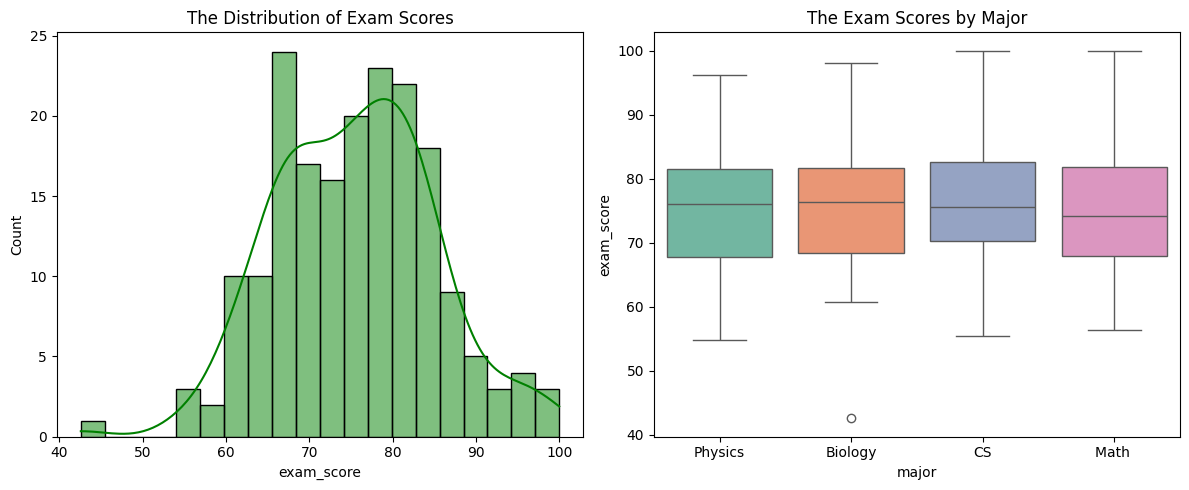

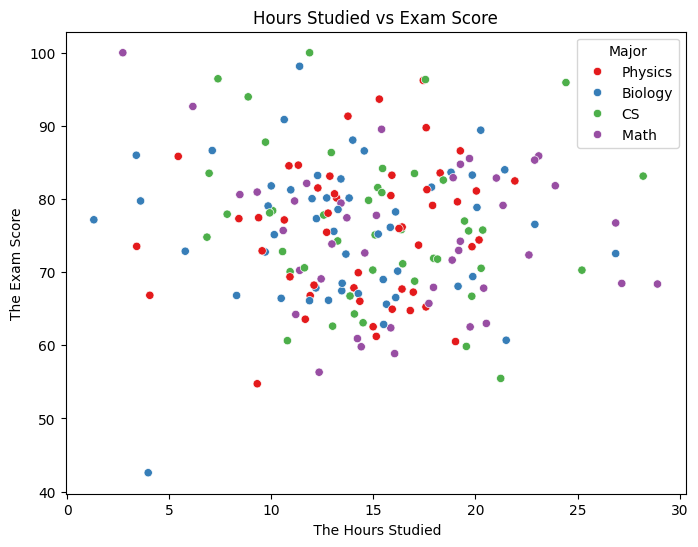

/tmp/ipykernel_4745/2330634740.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='major',y='exam_score', data=df,estimator= np.mean, palette='Set3')
/tmp/ipykernel_4745/2330634740.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='year', data=df, palette='Set2')
/tmp/ipykernel_4745/2330634740.py:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='performance', y= 'exam_score', data=df, palette='Set1')


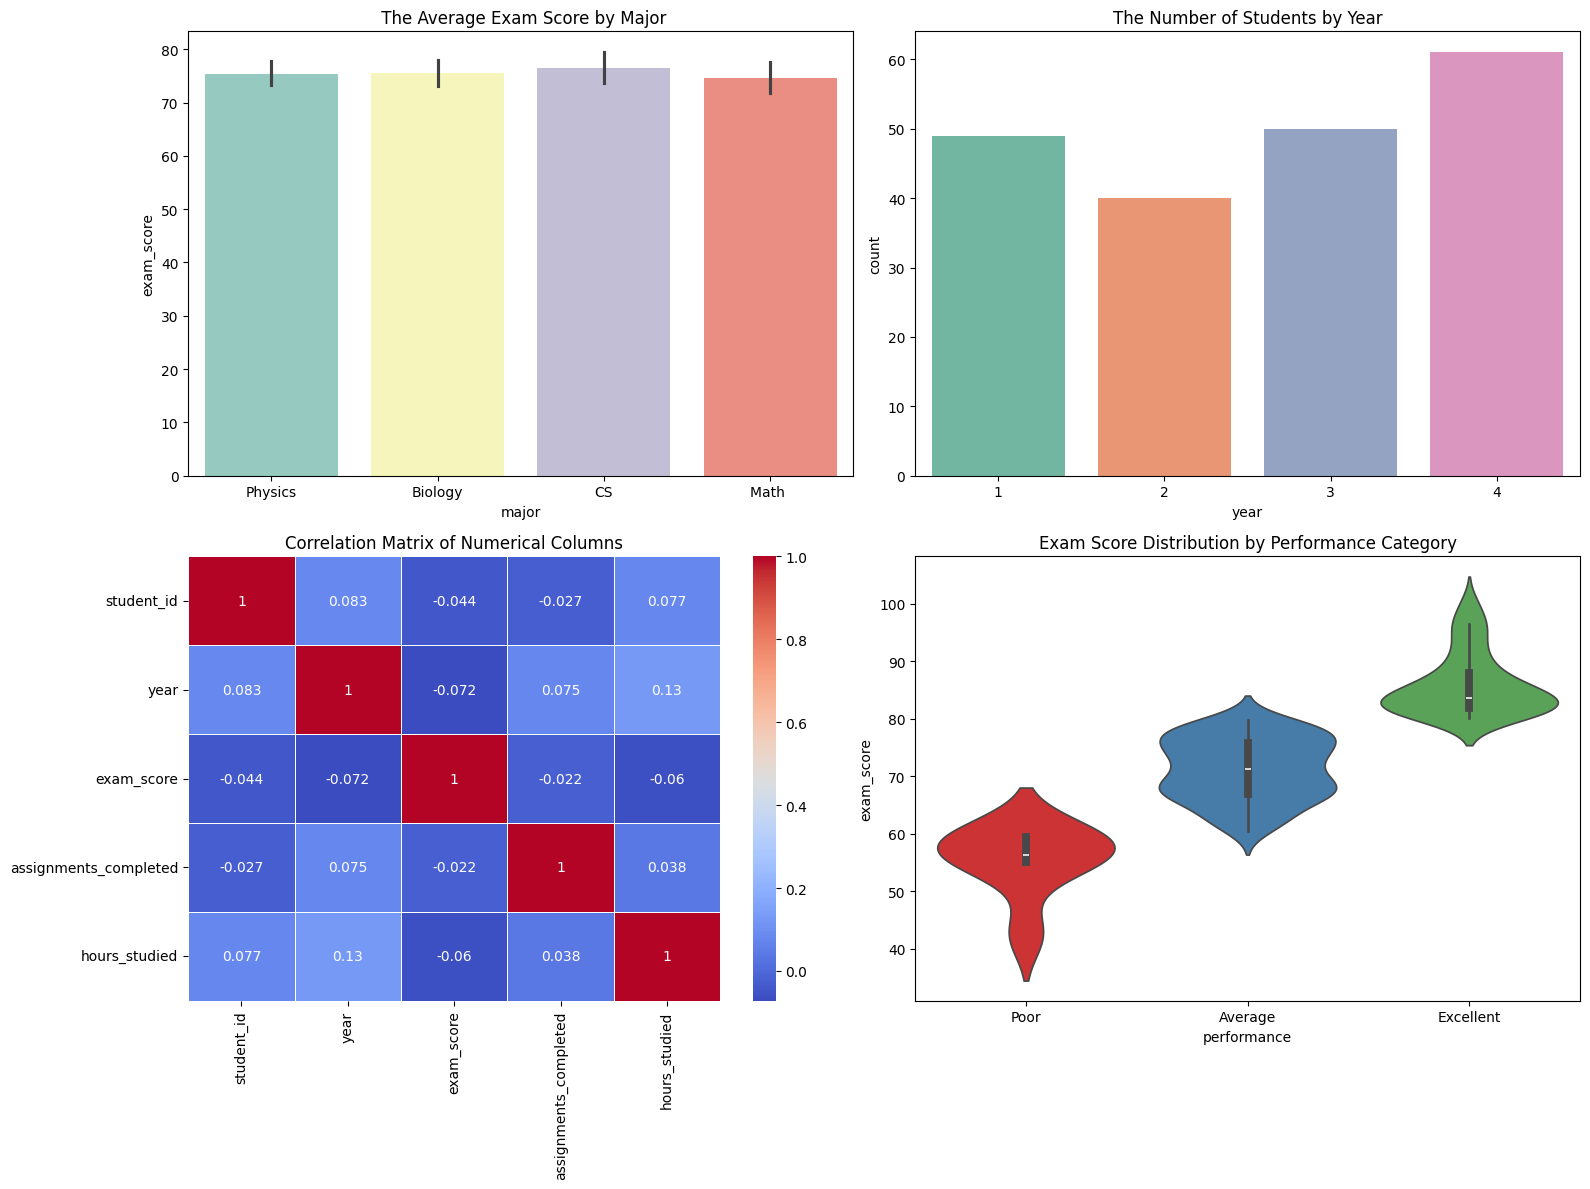

In [2]:
#Exercise 6
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200



data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math ', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

df['performance'] = pd.cut(df['exam_score'], bins=[0, 60, 80, 100], labels=['Poor', 'Average',  'Excellent'])
print(f"Performance distribution:\n{df['performance'].value_counts()}")



#Task 1
#figure with two subplots
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

#histogram of exam scores

sns.histplot(df['exam_score'], bins=20, kde=True, color='green')
plt.title('The Distribution of Exam Scores')
plt.subplot(1, 2, 2)

#boxplot of exam scores by major
sns.boxplot(x='major', y='exam_score', data=df, palette='Set2')


#title,layout,etc
plt.title('The Exam Scores by Major')

plt.tight_layout()
plt.show()


#task2
#scatter plot of hours studied vs exam score
plt.figure(figsize=(8, 6))
#creating a scatter plot, coloring points by major using hue
sns.scatterplot(x='hours_studied', y='exam_score', data=df, hue='major', palette='Set1')

#titless,lables
plt.title('Hours Studied vs Exam Score')
plt.xlabel(' The Hours Studied')
plt.ylabel('The Exam Score')

plt.legend(title='Major')
plt.show()

#task3
#2x2 subplot
#bar plot of average exam score by major
plt.figure(figsize=(16, 12))
plt.subplot(2, 2, 1)
sns.barplot(x='major',y='exam_score', data=df,estimator= np.mean, palette='Set3')
plt.title(' The Average Exam Score by Major')

#`countplot of students by year`
plt.subplot(2, 2, 2)
sns.countplot(x='year', data=df, palette='Set2')
plt.title('The Number of Students by Year')

#correlation heatmap of numerical columns
plt.subplot(2, 2, 3)
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numerical Columns')

# the violin plot of exam scores by performance category
plt.subplot(2, 2, 4)
sns.violinplot(x='performance', y= 'exam_score', data=df, palette='Set1')
plt.title('Exam Score Distribution by Performance Category')
plt.tight_layout()
plt.show()


0       937.397271
1       370.085023
2       418.424348
3       477.171887
4      1097.651683
          ...     
495     750.052567
496     408.682977
497     276.305018
498    1149.667906
499     780.543489
Name: CLV, Length: 500, dtype: float64
  age_group  num_of_customers  average_income  average_clv      total_clv
0     18-25               107    48238.557026   719.337051   76969.064481
1     26-35               139    50351.665237   772.645676  107397.748987
2     36-50               158    48792.765157   728.320968  115074.712932
3     51-70                96    51933.177332   754.582312   72439.901993
Top 10% customers by CLV:
     age        income  purchase_frequency  avg_purchase_value  churn_risk  \
6     38  58876.388563                  10          110.331527    0.166667   
9     40  48809.492879                  10          110.228581    0.166667   
19    41  21282.756976                   8          119.651218    0.333333   
24    38  53981.193911                   8  

/tmp/ipykernel_4745/2931787889.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_age_group = customers.groupby('age_group').agg(num_of_customers=('age','count'),average_income=('income','mean'),average_clv=('CLV','mean'),total_clv=('CLV','sum')).reset_index()
/tmp/ipykernel_4745/2931787889.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group',y='CLV', data=customers, estimator=np.mean, palette='Set2')


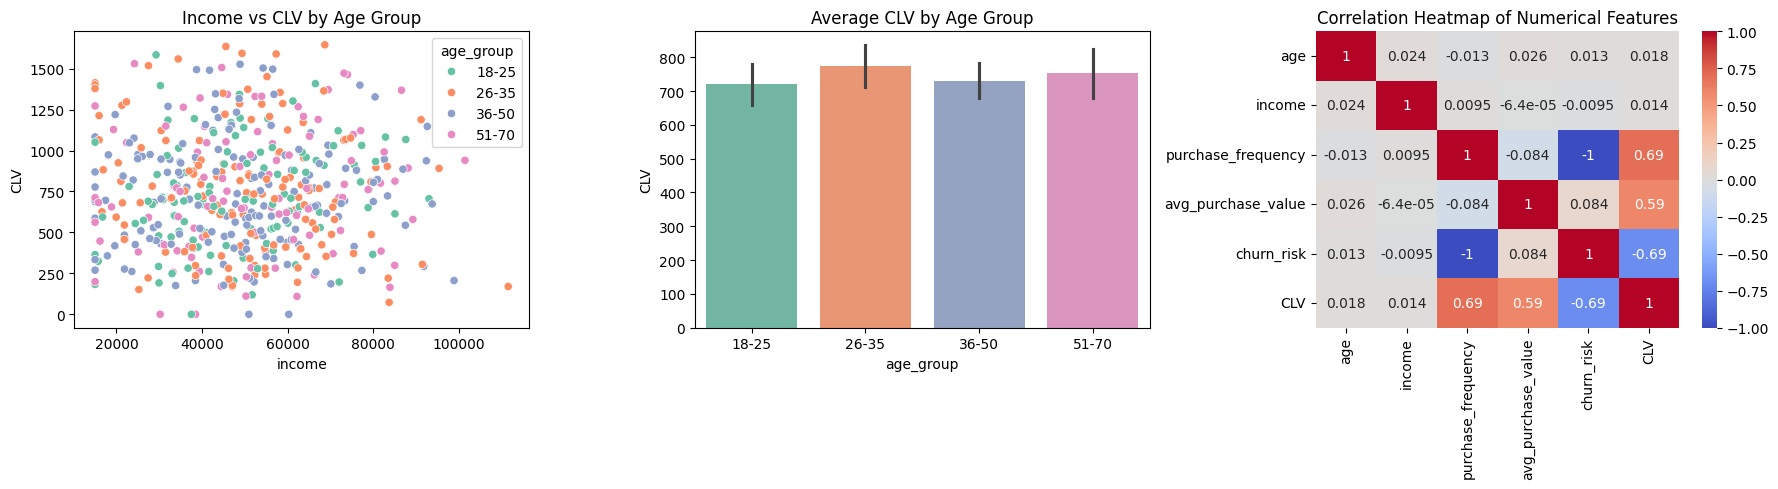

In [3]:
#Exercise 7

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})


#customer lifetime value (CLV) calculation
#       CLV = purchase_frequency * avg_purchase_value * (1 + churn_risk)
#       where churn_risk = 1 - (purchase_frequency / max_frequency)

max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])
print(customers['CLV'])



#creating age groups
bins = [18, 30, 45, 60, 70]
labels = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = pd.cut(customers['age'], bins=bins, labels=labels, right=False)
summary_age_group = customers.groupby('age_group').agg(num_of_customers=('age','count'),average_income=('income','mean'),average_clv=('CLV','mean'),total_clv=('CLV','sum')).reset_index()
print(summary_age_group)

# identifying top 10% customers by CLV
top_10_percent_threshold = customers['CLV'].quantile(0.9)
top_customers = customers[customers['CLV'] >= top_10_percent_threshold]
print(f"Top 10% customers by CLV:\n{top_customers}")

#creating visualizaton
#scatterplot of income vs CLV, colored by age group
plt.figure(figsize=(18, 5))
plt.subplot(1, 3, 1)
sns.scatterplot(x='income', y='CLV', data=customers, hue='age_group', palette='Set2')
plt.title('Income vs CLV by Age Group')

#barchart
plt.subplot(1, 3, 2)
sns.barplot(x='age_group',y='CLV', data=customers, estimator=np.mean, palette='Set2')
plt.title('Average CLV by Age Group')


#heatmap of correlation between numerical features
plt.subplot(1, 3, 3)
sns.heatmap(customers.select_dtypes(include=np.number).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

